# 🤖 Agente ReAct con LangGraph

Implementación del grafo LangGraph basado en el diagrama:

```
INICIO
  └─> ENTRADA Y FILTRO (SEGURIDAD)
        └─> AGENTE / LLM  <──────────────────────────┐
              │  ↕ LEER/ESCRIBIR                      │
         MEMORIA DE CHAT                              │
              │                                       │
              ├─> HERRAMIENTAS (RAG / API Clima / Export)
              │         └─> OBSERVACIÓN / SALIDA ─────┘
              │
              └─> RESPUESTA Y FILTRO (CONTROL)
                        └─> FIN
```

**Bucle ReAct**: DECISIÓN → ACCIÓN → OBSERVACIÓN (se repite hasta que el agente decide responder)

## 📦 1. Instalación de dependencias

In [55]:
!pip install -q langgraph langchain langchain-openai langchain-community \
    langchain-core faiss-cpu tiktoken python-dotenv requests

## ⚙️ 2. Configuración de variables de entorno

In [56]:
from langchain_openai import AzureOpenAIEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()

embeddings = AzureOpenAIEmbeddings(
    azure_deployment=os.getenv("AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT"),  # "text-embedding-ada-002"
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
)


## 📚 3. Importaciones

In [57]:
import json
import datetime
import requests
from typing import Annotated, Literal

# LangChain core
from langchain_core.messages import (
    AIMessage, HumanMessage, SystemMessage,
    ToolMessage, BaseMessage
)
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# LangChain OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# LangChain Community (RAG)
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# LangGraph
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

# Typing
from typing_extensions import TypedDict

print("✅ Importaciones completadas.")

✅ Importaciones completadas.


## 🗃️ 4. Estado del grafo (AgentState)

El estado es la "memoria de trabajo" que se comparte entre todos los nodos del grafo.

In [58]:
class AgentState(TypedDict):
    """Estado compartido entre todos los nodos del grafo."""

    # Lista de mensajes del hilo de conversación (add_messages hace append automático)
    messages: Annotated[list[BaseMessage], add_messages]

    # Input original del usuario (para referencia en filtros)
    user_input: str

    # Respuesta final generada por el agente
    final_response: str

    # Indicador de si el input fue bloqueado por seguridad
    blocked: bool

    # Número de iteraciones del bucle ReAct (anti-bucle infinito)
    iteration_count: int

    # Historial exportable del chat
    chat_export: list[dict]

print("✅ AgentState definido.")

✅ AgentState definido.


## 🔍 5. Base de conocimiento RAG

Creamos un vectorstore FAISS con documentos de ejemplo. En producción cargarías PDFs, webs, etc.

In [59]:
import os
from dotenv import load_dotenv
from langchain_openai import AzureOpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# 1. Cargar las variables de tu archivo .env
load_dotenv()

SAMPLE_DOCS = [
    "LangGraph es un framework de flujos de trabajo basado en grafos para agentes de IA. "
    "Permite definir nodos (funciones) y aristas (conexiones) para orquestar LLMs.",
    "LangChain es una librería Python para construir aplicaciones con LLMs. "
    "Proporciona herramientas para chains, agentes, memoria y retrieval.",
    "El patrón ReAct (Razonamiento + Actuación) permite a los LLMs razonar sobre "
    "qué herramientas usar, ejecutarlas y observar los resultados iterativamente.",
    "FAISS (Facebook AI Similarity Search) es una librería para búsqueda eficiente "
    "de vectores de embeddings. Se usa mucho en sistemas RAG.",
    "Los agentes de IA pueden usar herramientas como APIs del clima, bases de datos, "
    "o buscadores web para obtener información actualizada y responder preguntas."
]

# 2. Construir el vectorstore usando la configuración de AZURE
embeddings = AzureOpenAIEmbeddings(
    azure_deployment=os.environ.get("AZURE_OPENAI_EMBEDDINGS_DEPLOYMENT"),
    openai_api_version=os.environ.get("AZURE_OPENAI_API_VERSION"),
    azure_endpoint=os.environ.get("AZURE_OPENAI_ENDPOINT"),
    api_key=os.environ.get("AZURE_OPENAI_API_KEY")
)

docs = [Document(page_content=text) for text in SAMPLE_DOCS]

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

vectorstore = FAISS.from_documents(split_docs, embeddings)
retriever   = vectorstore.as_retriever(search_kwargs={"k": 2})

print(f"✅ Vectorstore RAG creado con {len(split_docs)} fragmentos.")

✅ Vectorstore RAG creado con 5 fragmentos.


## 🛠️ 6. Herramientas del agente

Implementamos las tres herramientas del diagrama: **RAG**, **API Clima** y **Exportar Chat**.

In [60]:
# ─────────────────────────────────────────────────────────
# HERRAMIENTA 1: Búsqueda RAG
# ─────────────────────────────────────────────────────────
@tool
def busqueda_rag(query: str) -> str:
    """Busca información en la base de conocimiento interna usando RAG (Retrieval-Augmented Generation).
    Úsala cuando necesites información sobre LangChain, LangGraph, IA o temas de la base de datos.

    Args:
        query: La pregunta o términos de búsqueda.
    """
    docs = retriever.invoke(query)
    if not docs:
        return "No se encontraron resultados relevantes en la base de conocimiento."
    resultados = "\n\n".join(
        [f"[Fragmento {i+1}]: {d.page_content}" for i, d in enumerate(docs)]
    )
    return f"📚 Resultados RAG para '{query}':\n{resultados}"


# ─────────────────────────────────────────────────────────
# HERRAMIENTA 2: API del Clima
# ─────────────────────────────────────────────────────────
@tool
def api_clima(ciudad: str) -> str:
    """Obtiene el clima actual de una ciudad usando la API de OpenWeatherMap.
    Úsala cuando el usuario pregunte por el tiempo, temperatura o condiciones meteorológicas.

    Args:
        ciudad: Nombre de la ciudad (en español o inglés).
    """
    if not OPENWEATHER_API_KEY:
        # Respuesta simulada si no hay API key
        return (
            f"🌤️ [SIMULADO] Clima en {ciudad}: 22°C, parcialmente nublado. "
            "Humedad: 60%. Viento: 15 km/h. "
            "(Configura OPENWEATHER_API_KEY para datos reales)"
        )

    url = "https://api.openweathermap.org/data/2.5/weather"
    params = {
        "q": ciudad,
        "appid": OPENWEATHER_API_KEY,
        "units": "metric",
        "lang": "es"
    }
    try:
        resp = requests.get(url, params=params, timeout=5)
        resp.raise_for_status()
        data = resp.json()
        desc   = data["weather"][0]["description"].capitalize()
        temp   = data["main"]["temp"]
        feels  = data["main"]["feels_like"]
        hum    = data["main"]["humidity"]
        viento = data["wind"]["speed"]
        return (
            f"🌡️ Clima en {ciudad}: {desc}. "
            f"Temperatura: {temp}°C (sensación: {feels}°C). "
            f"Humedad: {hum}%. Viento: {viento} m/s."
        )
    except requests.exceptions.HTTPError as e:
        if resp.status_code == 404:
            return f"❌ Ciudad '{ciudad}' no encontrada. Verifica el nombre."
        return f"❌ Error HTTP {resp.status_code}: {e}"
    except Exception as e:
        return f"❌ Error al consultar el clima: {str(e)}"


# ─────────────────────────────────────────────────────────
# HERRAMIENTA 3: Exportar Chat
# ─────────────────────────────────────────────────────────
@tool
def exportar_chat(formato: str = "txt") -> str:
    """Exporta el historial del chat actual a un archivo. 
    Úsala cuando el usuario pida guardar, descargar o exportar la conversación.

    Args:
        formato: Formato de exportación ('txt' o 'json').
    """
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename  = f"chat_export_{timestamp}.{formato}"

    # Nota: en el nodo real, el historial completo se pasará desde el estado.
    # Aquí generamos un archivo de placeholder.
    contenido = (
        f"Exportación del chat - {datetime.datetime.now().isoformat()}\n"
        "(El historial completo se guarda desde el estado del grafo)\n"
    )
    if formato == "json":
        contenido = json.dumps({"timestamp": timestamp, "nota": "Exportación desde LangGraph"}, indent=2)

    with open(filename, "w", encoding="utf-8") as f:
        f.write(contenido)

    return f"✅ Chat exportado correctamente como '{filename}'."


# Lista de herramientas disponibles
TOOLS = [busqueda_rag, api_clima, exportar_chat]
print(f"✅ {len(TOOLS)} herramientas registradas: {[t.name for t in TOOLS]}")

✅ 3 herramientas registradas: ['busqueda_rag', 'api_clima', 'exportar_chat']


## 🧠 7. Modelo LLM con herramientas vinculadas

In [61]:
import os
from dotenv import load_dotenv
from langchain_openai import AzureChatOpenAI

# 1. Cargar las variables del archivo .env
load_dotenv()

# 2. Instanciar el modelo usando la clase de Azure
llm = AzureChatOpenAI(
    azure_deployment=os.getenv("AZURE_OPENAI_DEPLOYMENT"),  # Ej: gpt-4o-mini
    openai_api_version=os.getenv("AZURE_OPENAI_API_VERSION"), # Ej: 2024-02-01
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    temperature=0  # 0 = respuestas más deterministas
)

# 3. Vincular las herramientas al modelo (asegúrate de que TOOLS esté definido previamente)
llm_con_tools = llm.bind_tools(TOOLS)

print("✅ LLM configurado y herramientas vinculadas.")

✅ LLM configurado y herramientas vinculadas.


## 🏗️ 8. Nodos del grafo

Implementamos cada nodo del diagrama como una función Python.

In [62]:
# ─── Control de verbosidad de los nodos ───────────────────────
VERBOSE_NODES = False   # ← True para ver el flujo interno, False para chat limpio
# ──────────────────────────────────────────────────────────────

# ─────────────────────────────────────────────────────────────────────────────
# NODO 1: ENTRADA Y FILTRO DE SEGURIDAD
# ─────────────────────────────────────────────────────────────────────────────

PATRONES_BLOQUEADOS = [
    "hack", "exploit", "malware", "virus", "bomba", "arma",
    "contraseña", "password", "crack", "robar", "ilegal",
    "inject", "sql injection", "xss", "bypass"
]

def nodo_entrada_filtro(state: AgentState) -> AgentState:
    """Nodo: ENTRADA Y FILTRO (SEGURIDAD)."""
    if VERBOSE_NODES: print("\n🔒 [NODO] Entrada y Filtro de Seguridad")

    ultimo_mensaje = state["messages"][-1]
    user_input = ultimo_mensaje.content if hasattr(ultimo_mensaje, "content") else ""
    input_lower = user_input.lower()

    if len(user_input.strip()) < 2:
        if VERBOSE_NODES: print("  ⚠️  Input demasiado corto. Bloqueado.")
        return {
            **state,
            "user_input": user_input,
            "blocked": True,
            "final_response": "⚠️ Por favor, escribe una pregunta o mensaje más completo.",
            "iteration_count": 0,
            "chat_export": state.get("chat_export", [])
        }

    for patron in PATRONES_BLOQUEADOS:
        if patron in input_lower:
            if VERBOSE_NODES: print(f"  🚫 Patrón bloqueado detectado: '{patron}'")
            return {
                **state,
                "user_input": user_input,
                "blocked": True,
                "final_response": (
                    f"🚫 Tu mensaje ha sido bloqueado por el filtro de seguridad. "
                    f"El contenido relacionado con '{patron}' no está permitido."
                ),
                "iteration_count": 0,
                "chat_export": state.get("chat_export", [])
            }

    if VERBOSE_NODES:
        print(f"  ✅ Input aprobado: '{user_input[:60]}...'" if len(user_input) > 60 else f"  ✅ Input aprobado: '{user_input}'")

    return {
        **state,
        "user_input": user_input,
        "blocked": False,
        "iteration_count": 0,
        "chat_export": state.get("chat_export", [])
    }


# ─────────────────────────────────────────────────────────────────────────────
# NODO 2: AGENTE / LLM
# ─────────────────────────────────────────────────────────────────────────────

MAX_ITERATIONS = 5

SYSTEM_PROMPT = """Eres un asistente de IA inteligente con acceso a herramientas. 
Puedes usar:
  - `busqueda_rag`: Para buscar información en la base de conocimiento interna.
  - `api_clima`: Para obtener el clima actual de una ciudad.
  - `exportar_chat`: Para guardar el historial de la conversación.

Razona paso a paso (ReAct) antes de responder. Si necesitas información, 
usa las herramientas disponibles. Responde siempre en español de forma clara y útil.
Si ya tienes suficiente información, responde directamente sin usar más herramientas."""

def nodo_agente(state: AgentState) -> AgentState:
    """Nodo: AGENTE / LLM."""
    if VERBOSE_NODES: print(f"\n🤖 [NODO] Agente/LLM (iteración {state['iteration_count'] + 1}/{MAX_ITERATIONS})")

    mensajes = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    respuesta = llm_con_tools.invoke(mensajes)

    if VERBOSE_NODES:
        if respuesta.tool_calls:
            print(f"  🔧 Herramientas a usar: {[tc['name'] for tc in respuesta.tool_calls]}")
        else:
            content_str = str(respuesta.content)
            print(f"  💬 Respuesta directa: '{content_str[:80]}...'"
                  if len(content_str) > 80 else f"  💬 Respuesta directa: '{content_str}'")

    return {
        **state,
        "messages": [respuesta],
        "iteration_count": state["iteration_count"] + 1
    }


# ─────────────────────────────────────────────────────────────────────────────
# NODO 3: HERRAMIENTAS
# ─────────────────────────────────────────────────────────────────────────────
nodo_herramientas = ToolNode(TOOLS)


# ─────────────────────────────────────────────────────────────────────────────
# NODO 4: RESPUESTA Y FILTRO (CONTROL)
# ─────────────────────────────────────────────────────────────────────────────

def nodo_respuesta_filtro(state: AgentState) -> AgentState:
    """Nodo: RESPUESTA Y FILTRO (CONTROL)."""
    if VERBOSE_NODES: print("\n✅ [NODO] Respuesta y Filtro (Control)")

    if state.get("blocked"):
        return state

    ultimo = next(
        (m for m in reversed(state["messages"]) if isinstance(m, AIMessage)),
        None
    )

    respuesta_raw = ultimo.content if ultimo else "No se generó respuesta."

    if not respuesta_raw or len(str(respuesta_raw).strip()) < 5:
        respuesta_filtrada = "⚠️ El agente no generó una respuesta válida. Por favor, reformula tu pregunta."
    else:
        respuesta_filtrada = str(respuesta_raw)
        iteraciones = state.get("iteration_count", 0)
        respuesta_filtrada += f"\n\n---\n🔄 *Iteraciones ReAct: {iteraciones} | Conversación activa*"

    historial = state.get("chat_export", [])
    historial.append({
        "timestamp": datetime.datetime.now().isoformat(),
        "user": state.get("user_input", ""),
        "assistant": respuesta_filtrada
    })

    if VERBOSE_NODES: print(f"  📤 Respuesta lista ({len(respuesta_filtrada)} chars)")

    return {
        **state,
        "final_response": respuesta_filtrada,
        "chat_export": historial
    }


print("✅ Todos los nodos definidos.")


✅ Todos los nodos definidos.


## 🔀 9. Lógica de enrutamiento (aristas condicionales)

In [63]:
def router_despues_filtro_entrada(
    state: AgentState
) -> Literal["agente", "respuesta_filtro"]:
    """Después del filtro de entrada:
    - Si fue bloqueado → ir directamente a respuesta_filtro (para devolver el mensaje de bloqueo).
    - Si está permitido → ir al agente.
    """
    if state.get("blocked"):
        print("  🔀 Router: bloqueado → respuesta_filtro")
        return "respuesta_filtro"
    print("  🔀 Router: permitido → agente")
    return "agente"


def router_bucle_react(
    state: AgentState
) -> Literal["herramientas", "respuesta_filtro"]:
    """Bucle ReAct: después del agente:
    - Si el agente eligió una herramienta (ACCIÓN) → ejecutar herramientas.
    - Si el agente respondió directamente O alcanzamos el límite → respuesta_filtro.
    """
    ultimo_mensaje = state["messages"][-1]

    # Límite de iteraciones anti-bucle infinito
    if state.get("iteration_count", 0) >= MAX_ITERATIONS:
        print(f"  🔀 Router: límite de {MAX_ITERATIONS} iteraciones alcanzado → respuesta_filtro")
        return "respuesta_filtro"

    # Si el último mensaje de IA tiene tool_calls → ejecutar herramientas
    if isinstance(ultimo_mensaje, AIMessage) and ultimo_mensaje.tool_calls:
        print(f"  🔀 Router: herramientas detectadas → nodo_herramientas (ACCIÓN ReAct)")
        return "herramientas"

    print("  🔀 Router: respuesta final → respuesta_filtro")
    return "respuesta_filtro"


print("✅ Funciones de enrutamiento definidas.")

✅ Funciones de enrutamiento definidas.


## 🏗️ 10. Construcción del grafo LangGraph

Conectamos todos los nodos y aristas según el diagrama.

In [64]:
# ─────────────────────────────────────────────
# Memoria persistente entre conversaciones
# ─────────────────────────────────────────────
memory = MemorySaver()  # En producción usa SqliteSaver o PostgresSaver

# ─────────────────────────────────────────────
# Definición del grafo
# ─────────────────────────────────────────────
builder = StateGraph(AgentState)

# ── Añadir nodos ──────────────────────────────
builder.add_node("entrada_filtro",   nodo_entrada_filtro)
builder.add_node("agente",           nodo_agente)
builder.add_node("herramientas",     nodo_herramientas)     # OBSERVACIÓN / SALIDA
builder.add_node("respuesta_filtro", nodo_respuesta_filtro)

# ── Arista de inicio ──────────────────────────
# INICIO → entrada_filtro
builder.add_edge(START, "entrada_filtro")

# ── Arista condicional tras filtro de entrada ─
# entrada_filtro → agente  (si OK)
# entrada_filtro → respuesta_filtro  (si bloqueado)
builder.add_conditional_edges(
    "entrada_filtro",
    router_despues_filtro_entrada,
    {
        "agente":           "agente",
        "respuesta_filtro": "respuesta_filtro"
    }
)

# ── Bucle ReAct ───────────────────────────────
# agente → herramientas  (si hay tool_calls = ACCIÓN)
# agente → respuesta_filtro  (si respuesta final)
builder.add_conditional_edges(
    "agente",
    router_bucle_react,
    {
        "herramientas":     "herramientas",
        "respuesta_filtro": "respuesta_filtro"
    }
)

# ── OBSERVACIÓN: herramientas → agente ────────
# Los resultados de las herramientas vuelven al agente (OBSERVACIÓN ReAct)
builder.add_edge("herramientas", "agente")

# ── Arista final ──────────────────────────────
# respuesta_filtro → FIN
builder.add_edge("respuesta_filtro", END)

# ─────────────────────────────────────────────
# Compilar el grafo con memoria de chat
# ─────────────────────────────────────────────
grafo = builder.compile(checkpointer=memory)

print("✅ Grafo LangGraph compilado correctamente.")
print()
print("Nodos:",  list(grafo.get_graph().nodes.keys()))

✅ Grafo LangGraph compilado correctamente.

Nodos: ['__start__', 'entrada_filtro', 'agente', 'herramientas', 'respuesta_filtro', '__end__']


## 📊 11. Visualización del grafo

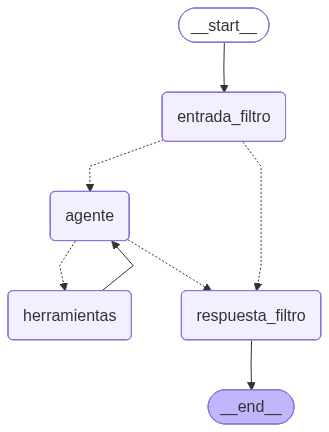

✅ Grafo visualizado.


In [65]:
try:
    from IPython.display import Image, display
    imagen = grafo.get_graph().draw_mermaid_png()
    display(Image(imagen))
    print("✅ Grafo visualizado.")
except Exception as e:
    print(f"ℹ️  No se pudo renderizar la imagen del grafo: {e}")
    print("   (Instala 'pygraphviz' o 'grandalf' para visualización)")
    print()
    # Mostrar representación en texto
    print("Estructura del grafo (Mermaid):")
    print(grafo.get_graph().draw_mermaid())

## 💬 12. Función de invocación del agente

In [66]:
def invocar_agente(
    mensaje: str,
    thread_id: str = "hilo-principal",
    verbose: bool = True
) -> str:
    """Invoca el agente con un mensaje del usuario."""
    config = {"configurable": {"thread_id": thread_id}}

    # ✅ FIX: Recuperar chat_export existente del checkpoint para no resetearlo
    estado_existente = grafo.get_state(config)
    chat_export_actual = []
    if estado_existente and estado_existente.values:
        chat_export_actual = estado_existente.values.get("chat_export", [])

    if verbose:
        print("=" * 60)
        print(f"👤 USUARIO: {mensaje}")
        print("=" * 60)

    estado_inicial = {
        "messages":       [HumanMessage(content=mensaje)],
        "user_input":     mensaje,
        "final_response": "",
        "blocked":        False,
        "iteration_count": 0,
        "chat_export":    chat_export_actual,   # ← preserva historial acumulado
    }

    resultado = grafo.invoke(estado_inicial, config=config)
    respuesta = resultado.get("final_response", "Sin respuesta generada.")

    if verbose:
        print()
        print("=" * 60)
        print("🤖 RESPUESTA FINAL:")
        print(respuesta)
        print("=" * 60)

    return respuesta

print("✅ Función de invocación lista.")


✅ Función de invocación lista.


## 🧪 13. Pruebas del agente

### Prueba 1: Pregunta que usa el RAG

In [67]:
respuesta1 = invocar_agente(
    "¿Qué es LangGraph y para qué sirve?",
    thread_id="sesion-demo-1"
)

👤 USUARIO: ¿Qué es LangGraph y para qué sirve?
  🔀 Router: permitido → agente
  🔀 Router: herramientas detectadas → nodo_herramientas (ACCIÓN ReAct)
  🔀 Router: respuesta final → respuesta_filtro

🤖 RESPUESTA FINAL:
LangGraph es un framework de flujos de trabajo basado en grafos diseñado para agentes de inteligencia artificial (IA). Su principal función es permitir la definición de nodos, que representan funciones, y aristas, que son las conexiones entre estos nodos. Esto facilita la orquestación de modelos de lenguaje (LLMs) en diversas aplicaciones.

En resumen, LangGraph se utiliza para estructurar y gestionar de manera eficiente los procesos y tareas que realizan los agentes de IA, mejorando su capacidad de interacción y ejecución de tareas complejas.

---
🔄 *Iteraciones ReAct: 2 | Conversación activa*


### Prueba 2: Pregunta del clima

In [68]:
respuesta2 = invocar_agente(
    "¿Qué tiempo hace hoy en Madrid?",
    thread_id="sesion-demo-2"
)

👤 USUARIO: ¿Qué tiempo hace hoy en Madrid?
  🔀 Router: permitido → agente
  🔀 Router: herramientas detectadas → nodo_herramientas (ACCIÓN ReAct)
  🔀 Router: respuesta final → respuesta_filtro

🤖 RESPUESTA FINAL:
Hoy en Madrid el clima es de cielo claro, con una temperatura de 27.48°C (sensación térmica de 27.35°C). La humedad es del 42% y el viento sopla a 1.79 m/s.

---
🔄 *Iteraciones ReAct: 2 | Conversación activa*


### Prueba 3: Exportar el chat

In [69]:
respuesta3 = invocar_agente(
    "Exporta esta conversación en formato txt.",
    thread_id="sesion-demo-3"
)

👤 USUARIO: Exporta esta conversación en formato txt.
  🔀 Router: permitido → agente
  🔀 Router: herramientas detectadas → nodo_herramientas (ACCIÓN ReAct)
  🔀 Router: respuesta final → respuesta_filtro

🤖 RESPUESTA FINAL:
La conversación ha sido exportada correctamente en formato TXT. Si necesitas algo más, no dudes en decírmelo.

---
🔄 *Iteraciones ReAct: 2 | Conversación activa*


## 💬 14. Modo Chat Interactivo

Ejecuta esta celda para chatear con el agente en tiempo real.

In [70]:
print("💬 Chat Interactivo con el Agente ReAct")
print("  Escribe 'salir' o 'exit' para terminar.")
print("─" * 50)

SESSION_ID = "sesion-interactiva"

while True:
    try:
        user_input = input("\n👤 Tú: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n👋 Chat finalizado.")
        break

    if not user_input:
        continue

    if user_input.lower() in ["salir", "exit", "quit"]:
        print("👋 ¡Hasta luego!")
        break

    # verbose=False para output limpio; los nodos ya son silenciosos con VERBOSE_NODES=False
    respuesta = invocar_agente(user_input, thread_id=SESSION_ID, verbose=False)
    print(f"\n🤖 Agente: {respuesta}")


💬 Chat Interactivo con el Agente ReAct
  Escribe 'salir' o 'exit' para terminar.
──────────────────────────────────────────────────
  🔀 Router: permitido → agente
  🔀 Router: respuesta final → respuesta_filtro

🤖 Agente: ¡Claro! La sopa es un platillo delicioso y reconfortante. ¿Tienes algún tipo de sopa en mente, como sopa de pollo, de verduras, o alguna receta específica que te gustaría preparar? También puedo sugerirte algunas recetas si lo prefieres.

---
🔄 *Iteraciones ReAct: 1 | Conversación activa*
  🔀 Router: permitido → agente
  🔀 Router: respuesta final → respuesta_filtro

🤖 Agente: ¡Perfecto! Aquí tienes una receta sencilla para preparar una sopa de garbanzos:

### Sopa de Garbanzos

#### Ingredientes:
- 1 taza de garbanzos (remojados durante la noche o de lata)
- 1 cebolla picada
- 2 dientes de ajo picados
- 1 zanahoria picada
- 1 pimiento rojo picado
- 2 tomates pelados y picados (o 1 taza de tomate triturado)
- 4 tazas de caldo de verduras o pollo
- 1 hoja de laurel
- Sal

## 📁 15. Ver historial exportable del chat

In [71]:
# Celda 15 — cambia a la sesión del chat interactivo
config_memoria = {"configurable": {"thread_id": "sesion-interactiva"}}  # ← este es el tuyo
estado_actual = grafo.get_state(config_memoria)

if estado_actual and estado_actual.values:
    historial = estado_actual.values.get("chat_export", [])
    print(f"📋 Historial de la sesión 'sesion-interactiva' ({len(historial)} turnos):")
    print()
    for i, turno in enumerate(historial, 1):
        print(f"── Turno {i} [{turno['timestamp']}] ──")
        print(f"   👤 {turno['user']}")
        print(f"   🤖 {turno['assistant'][:200]}..."
              if len(turno['assistant']) > 200
              else f"   🤖 {turno['assistant']}")
        print()
else:
    print("ℹ️  No hay historial para esta sesión aún.")


📋 Historial de la sesión 'sesion-interactiva' (2 turnos):

── Turno 1 [2026-06-08T12:50:40.679104] ──
   👤 quiero sopa
   🤖 ¡Claro! La sopa es un platillo delicioso y reconfortante. ¿Tienes algún tipo de sopa en mente, como sopa de pollo, de verduras, o alguna receta específica que te gustaría preparar? También puedo suger...

── Turno 2 [2026-06-08T12:51:02.510934] ──
   👤 con garbanzos
   🤖 ¡Perfecto! Aquí tienes una receta sencilla para preparar una sopa de garbanzos:

### Sopa de Garbanzos

#### Ingredientes:
- 1 taza de garbanzos (remojados durante la noche o de lata)
- 1 cebolla pica...



---

## 📌 Resumen de la arquitectura

| Nodo | Función | Equivalente en diagrama |
|------|---------|------------------------|
| `entrada_filtro` | Valida y filtra el input del usuario | ENTRADA Y FILTRO (SEGURIDAD) |
| `agente` | LLM con tool calling (ReAct: DECISIÓN) | AGENTE / LLM |
| `herramientas` | Ejecuta RAG, Clima, Export (ACCIÓN) | HERRAMIENTAS + OBSERVACIÓN/SALIDA |
| `respuesta_filtro` | Formatea y valida la respuesta final | RESPUESTA Y FILTRO (CONTROL) |
| `messages` en estado | Historial completo de la conversación | MEMORIA DE CHAT |

### 🔄 Bucle ReAct

```
agente (DECISIÓN)
   ↓ si tool_calls
herramientas (ACCIÓN)
   ↓ resultado
agente (OBSERVACIÓN → nueva DECISIÓN)
   ↓ si respuesta final
respuesta_filtro → FIN
```